Linear Regression. 

Hands-On Lab:

   1- Train a LinearRegression model on a provided regression dataset.

   2- Report the model's coefficients and identify which feature has the strongest effect.

   3- Evaluate the model with MAE, RMSE, and R² on the test set.

   4- Compare the RMSE against a baseline that predicts the mean for every row, and state whether the 
    model adds value.

   5- Document the interpretation of results in Markdown.


In [6]:
import matplotlib.pyplot as plt # data visualization 
import numpy as np # data manipulation

In [8]:
from sklearn.datasets import fetch_california_housing # dataSet

from sklearn.model_selection import train_test_split # data split mechanizm

from sklearn.linear_model import LinearRegression # model 

from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score # model evaluation metrics

In [ ]:
model = LinearRegression() # model object

cal_housing = fetch_california_housing() # dataSet object

X = cal_housing.data # features
y = cal_housing.target # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # data split

model.fit(X_train, y_train) # model training

prediction = model.predict(X_test) # model prediction


In [23]:
print(f"Model Coefficients: {model.coef_}\n") # model coefficients

print(f"Model Intercept: {model.intercept_}\n") # model intercept


for feature, coef in zip(cal_housing.feature_names, model.coef_): # printing feature names and their coefficients
    print(f"{feature}: {coef}")

Model Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]

Model Intercept: -37.02327770606397

MedInc: 0.44867490966571894
HouseAge: 0.009724257517905413
AveRooms: -0.12332334282795913
AveBedrms: 0.7831449067929733
Population: -2.029620580143443e-06
AveOccup: -0.0035263184871342293
Latitude: -0.41979248658835716
Longitude: -0.4337080649639876


Taking the absolute value of coeffecients: AveBedroms: 0.7831449067929733 is the largest raw coeffecient.

--raw coefficient sizes are not directly comparable because the features have different scales--

In [ ]:
print (f"(using model.score) R^2 Score: {model.score(X_test, y_test)}") # model evaluation using R^2 score

mae = mean_absolute_error(y_test, prediction) # model evaluation using MAE
print(f"MAE: {mae}") 

mse = mean_squared_error(y_test, prediction) # model evaluation using MSE
print(f"MSE: {mse}") 

rmse = mse**.5 # model evaluation using Root Mean Squared Error (RMSE)
print(f"RMSE: {rmse}")

r2 = r2_score(y_test, prediction) # model evaluation using R^2 score
print(f"R^2 Score: {r2}") 

Model Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]

Model Intercept: -37.02327770606397

(using model.score) R^2 Score: 0.5757877060324521
MAE: 0.5332001304956989
MSE: 0.5558915986952425
RMSE: 0.7455813830127751
R^2 Score: 0.5757877060324521


MAE answers:  
    On average, how far are the model’s predictions from the real house values? 

RMSE:   
    measures prediction error, but it gives extra weight to large mistakes. 

R²:     
     is about how well the model explains the overall variation across the dataset, not the accuracy of one individual prediction.

        meaning those features, as combined by linear regression, account for a meaningful part of those differences, but not all of them.


Baseline that predicts the mean for every row:

In [ ]:
baseline_mean = np.mean(y_train) # training set mean

baseline_prediction = np.full(y_test.shape, baseline_mean) # baseline prediction using "full function": which creates an array of the (same shape) as 'y_test' and fills it with the mean value of the training set

array([2.07194694, 2.07194694, 2.07194694, ..., 2.07194694, 2.07194694,
       2.07194694], shape=(4128,))

Baseline Rmse:

In [ ]:
baseline_rmse = mean_squared_error(y_test, baseline_prediction)**.5  # baseline model evaluation using RMSE

print (f"Baseline RMSE: {baseline_rmse}") 

print (f"Linear Regression RMSE: {rmse}")

Baseline RMSE: 1.1448563543099792
Linear Regression RMSE: 0.7455813830127751


Comparing the two RMSE value:

In [27]:
if rmse < baseline_rmse:
    print("The Linear Regression model performs better than the baseline model.")
else: 
    print("The baseline model performs better than the Linear Regression model.")

The Linear Regression model performs better than the baseline model.


The linear regression model adds value because its RMSE is lower than the baseline RMSE.

Meaning that It makes better predictions than simply predicting the average house value for every district.

The model achieved an MAE of approximately 0.533. Meaning that the predictions differ from the actual target by about $53,320 on average.

The model achieved an RMSE of approximately 0.746, or roughly $74,560. RMSE is larger than MAE because it penalizes large prediction errors more strongly.

The R² score is approximately 0.576. The model explains about 57.6% of the variation in house values in the test set.

The model outperforms the mean baseline, so it adds predictive value.

The model is useful but not highly accurate, approximately 42.4% of the variation remains unexplained.

Relationships in the housing data may be nonlinear.

""target is measured in units of $100,000""

Simple Visualization:    
Scatter plot of actual vs predicted values:

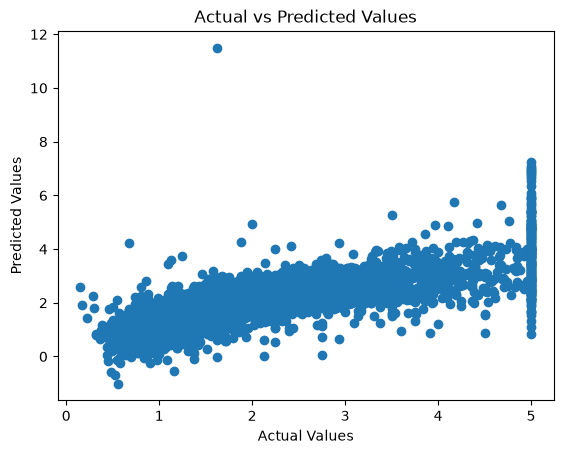

In [ ]:
plt.scatter(y_test, prediction)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()